In [6]:
import os

os.listdir("/content")


['.config', 'northstar_dataset', 'sample_data']

In [7]:
import zipfile
import os

zip_path = "/northstar_dataset.zip"
extract_path = "/content/northstar_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)

['northstar_dataset']

In [8]:
import os

correct_path = "/content/northstar_dataset/northstar_dataset"

os.listdir(correct_path)

['deliveries.csv',
 'orders.csv',
 'hubs.csv',
 'customers.csv',
 'app_events.csv',
 'data_dictionary.csv',
 'complaints.csv',
 'incidents.csv',
 'vehicles.csv',
 'README.txt',
 'drivers.csv']

In [9]:
import pandas as pd
import numpy as np

path = "/content/northstar_dataset/northstar_dataset"

orders = pd.read_csv(f"{path}/orders.csv")
deliveries = pd.read_csv(f"{path}/deliveries.csv")
customers = pd.read_csv(f"{path}/customers.csv")
complaints = pd.read_csv(f"{path}/complaints.csv")
incidents = pd.read_csv(f"{path}/incidents.csv")
drivers = pd.read_csv(f"{path}/drivers.csv")
vehicles = pd.read_csv(f"{path}/vehicles.csv")
hubs = pd.read_csv(f"{path}/hubs.csv")
app_events = pd.read_csv(f"{path}/app_events.csv")
data_dictionary = pd.read_csv(f"{path}/data_dictionary.csv")

print("All NorthStar CSV files loaded successfully.")

All NorthStar CSV files loaded successfully.


In [10]:
orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [11]:
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [12]:
datasets = {
    "orders": orders,
    "deliveries": deliveries,
    "customers": customers,
    "complaints": complaints,
    "incidents": incidents,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "app_events": app_events
}

for name, df in datasets.items():
    print(name, ":", df.shape)

orders : (1250, 11)
deliveries : (950, 13)
customers : (650, 9)
complaints : (320, 10)
incidents : (280, 7)
drivers : (170, 8)
vehicles : (120, 8)
hubs : (8, 5)
app_events : (640, 10)


In [13]:
for name, df in datasets.items():
    print("\n" + name.upper())
    print(df.columns.tolist())


ORDERS
['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag']

DELIVERIES
['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost']

CUSTOMERS
['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status']

COMPLAINTS
['complaint_id', 'customer_id', 'order_id', 'complaint_type', 'channel', 'severity', 'created_at', 'status', 'resolution_days', 'compensation_amount']

INCIDENTS
['incident_id', 'delivery_id', 'incident_type', 'reported_at', 'severity', 'resolution_status', 'resolved_hours']

DRIVERS
['driver_id', 'base_zone', 'employment_type', 'years_experienc

In [14]:
for name, df in datasets.items():
    print("\n" + name.upper())
    print(df.isnull().sum())


ORDERS
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

DELIVERIES
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64

CUSTOMERS
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_e

In [15]:
for name, df in datasets.items():
    print(name, "duplicates:", df.duplicated().sum())

orders duplicates: 0
deliveries duplicates: 0
customers duplicates: 0
complaints duplicates: 0
incidents duplicates: 0
drivers duplicates: 0
vehicles duplicates: 0
hubs duplicates: 0
app_events duplicates: 0


In [16]:
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1250 non-null   object 
 1   customer_id            1250 non-null   object 
 2   service_type           1250 non-null   object 
 3   order_created_at       1250 non-null   object 
 4   promised_window_hours  1250 non-null   int64  
 5   pickup_zone            1250 non-null   object 
 6   dropoff_zone           1250 non-null   object 
 7   priority_level         1250 non-null   object 
 8   order_value            1250 non-null   float64
 9   booking_channel        1225 non-null   object 
 10  special_handling_flag  1250 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 107.6+ KB


In [17]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delivery_id                    950 non-null    object 
 1   order_id                       950 non-null    object 
 2   driver_id                      950 non-null    object 
 3   vehicle_id                     950 non-null    object 
 4   hub_id                         950 non-null    object 
 5   dispatch_time                  950 non-null    object 
 6   delivery_completed_at          931 non-null    object 
 7   delivery_status                950 non-null    object 
 8   route_distance_km              950 non-null    float64
 9   manual_route_override_count    950 non-null    int64  
 10  proof_of_completion_missing    950 non-null    int64  
 11  customer_rating_post_delivery  936 non-null    float64
 12  fuel_or_charge_cost            950 non-null    flo

In [18]:
# Standardise zone names across all datasets

def clean_zone(value):
    if pd.isna(value):
        return value
    return str(value).strip().title()

# Orders
orders["pickup_zone"] = orders["pickup_zone"].apply(clean_zone)
orders["dropoff_zone"] = orders["dropoff_zone"].apply(clean_zone)

# Customers
customers["home_zone"] = customers["home_zone"].apply(clean_zone)

# Drivers
drivers["base_zone"] = drivers["base_zone"].apply(clean_zone)

# Vehicles
vehicles["assigned_zone"] = vehicles["assigned_zone"].apply(clean_zone)

# Hubs
hubs["zone"] = hubs["zone"].apply(clean_zone)

# App events
app_events["zone_context"] = app_events["zone_context"].apply(clean_zone)

print("Zone names cleaned successfully.")

Zone names cleaned successfully.


In [19]:
# Convert date and time columns to datetime format

orders["order_created_at"] = pd.to_datetime(orders["order_created_at"], errors="coerce")

deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"], errors="coerce")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce")

customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors="coerce")

complaints["created_at"] = pd.to_datetime(complaints["created_at"], errors="coerce")

incidents["reported_at"] = pd.to_datetime(incidents["reported_at"], errors="coerce")

app_events["event_timestamp"] = pd.to_datetime(app_events["event_timestamp"], errors="coerce")

print("Date and time columns converted successfully.")

Date and time columns converted successfully.


In [20]:
# Calculate actual delivery duration in hours

deliveries["actual_delivery_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

# Fix negative delivery hours if any appear
deliveries["actual_delivery_hours"] = deliveries["actual_delivery_hours"].apply(
    lambda x: np.nan if x < 0 else x
)

print(deliveries[["delivery_id", "order_id", "dispatch_time", "delivery_completed_at", "actual_delivery_hours"]].head())

  delivery_id order_id       dispatch_time      delivery_completed_at  \
0     DL00001   O00938 2024-06-18 10:57:00 2024-06-19 09:05:59.904311   
1     DL00002   O00004 2025-01-11 18:45:00 2025-01-11 17:39:00.000000   
2     DL00003   O00639 2025-06-02 20:39:00 2025-06-02 21:45:32.366770   
3     DL00004   O00313 2024-03-08 23:31:00 2024-03-09 23:30:08.103702   
4     DL00005   O00844 2025-09-21 11:43:00 2025-09-21 15:45:34.131056   

   actual_delivery_hours  
0              22.149973  
1                    NaN  
2               1.108991  
3              23.985584  
4               4.042814  


In [21]:
# Merge orders and deliveries using order_id

main_df = orders.merge(deliveries, on="order_id", how="left")

print("Orders and deliveries merged successfully.")
print(main_df.shape)
main_df.head()

Orders and deliveries merged successfully.
(1250, 24)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,actual_delivery_hours
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,H01,2024-08-20 16:29:00,2024-08-20 18:52:56.172161,OnTime,26.65,2.0,0.0,4.29,15.82,2.398937
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,H02,2025-09-02 16:59:00,2025-09-03 01:50:39.644673,Delayed,13.04,2.0,0.0,3.70,13.16,8.861012
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1.0,0.0,5.00,13.41,NaN
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,H03,2025-02-17 20:23:00,2025-02-18 08:05:00.047082,OnTime,16.01,1.0,0.0,4.38,13.53,11.700013


In [22]:
# Merge customer details using customer_id

main_df = main_df.merge(customers, on="customer_id", how="left")

print("Customer details added successfully.")
print(main_df.shape)
main_df.head()

Customer details added successfully.
(1250, 32)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,fuel_or_charge_cost,actual_delivery_hours,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,15.82,2.398937,24,South,Consumer,2025-03-02 11:24:00,73.2,57.9,App,Active
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,NaN,NaN,20,West,Consumer,2024-09-23 21:00:00,56.1,62.6,App,Dormant
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,13.16,8.861012,42,North,Consumer,2024-06-07 22:41:00,87.1,36.6,App,Active
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,13.41,NaN,50,North,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,13.53,11.700013,23,South,Consumer,2024-06-29 19:47:00,64.3,38.5,Phone,Active


In [23]:
# Merge hub details using hub_id

main_df = main_df.merge(hubs, on="hub_id", how="left", suffixes=("", "_hub"))

print("Hub details added successfully.")
print(main_df.shape)
main_df.head()

Hub details added successfully.
(1250, 36)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status,hub_name,zone,hub_type,capacity_score
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,Consumer,2025-03-02 11:24:00,73.2,57.9,App,Active,North Exchange,North,Dispatch,82.0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,Consumer,2024-09-23 21:00:00,56.1,62.6,App,Dormant,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,Consumer,2024-06-07 22:41:00,87.1,36.6,App,Active,South Link,South,Dispatch,78.0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active,South Link,South,Dispatch,78.0
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,Consumer,2024-06-29 19:47:00,64.3,38.5,Phone,Active,East Dock,East,Warehouse,74.0


In [25]:


main_df = main_df.merge(drivers, on="driver_id", how="left", suffixes=("", "_driver"))

print("Driver details added successfully.")
print(main_df.shape)
main_df.head()

Driver details added successfully.
(1250, 50)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,driver_rating,shift_preference,active_flag,base_zone_driver,employment_type_driver,years_experience_driver,training_score_driver,driver_rating_driver,shift_preference_driver,active_flag_driver
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,4.70,Morning,1.0,South,FullTime,7.0,64.6,4.70,Morning,1.0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,3.67,Morning,1.0,East,PartTime,3.0,88.2,3.67,Morning,1.0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,4.61,Evening,1.0,Ctr,PartTime,11.0,69.2,4.61,Evening,1.0
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,4.32,Morning,1.0,West,FullTime,3.0,80.1,4.32,Morning,1.0


In [27]:

main_df = main_df.merge(vehicles, on="vehicle_id", how="left", suffixes=("", "_vehicle"))

print("Vehicle details added successfully.")
print(main_df.shape)
main_df.head()

Vehicle details added successfully.
(1250, 64)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,odometer_km,maintenance_status,telematics_version,vehicle_type_vehicle,assigned_zone_vehicle,commission_date_vehicle,battery_health_pct_vehicle,odometer_km_vehicle,maintenance_status_vehicle,telematics_version_vehicle
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,98472.0,InRepair,v2.0,Hybrid,West,2024-08-16 01:10:00,93.8,98472.0,InRepair,v2.0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,31876.0,Active,v2.0,CargoVan,East,2024-06-23 11:24:00,60.1,31876.0,Active,v2.0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,78468.0,Active,v2.2,Diesel,Airport,2025-09-17 08:52:00,68.6,78468.0,Active,v2.2
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,191353.0,Active,v2.1,Hybrid,Airport,2024-05-28 05:33:00,NaN,191353.0,Active,v2.1


In [28]:
# Create complaint summary by order

complaint_summary = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    avg_resolution_days=("resolution_days", "mean"),
    total_compensation=("compensation_amount", "sum")
).reset_index()

main_df = main_df.merge(complaint_summary, on="order_id", how="left")

main_df["complaint_count"] = main_df["complaint_count"].fillna(0)
main_df["avg_resolution_days"] = main_df["avg_resolution_days"].fillna(0)
main_df["total_compensation"] = main_df["total_compensation"].fillna(0)

main_df["complaint_flag"] = np.where(main_df["complaint_count"] > 0, 1, 0)

print("Complaint summary added successfully.")
main_df[["order_id", "complaint_count", "complaint_flag", "avg_resolution_days", "total_compensation"]].head()

Complaint summary added successfully.


,order_id,complaint_count,complaint_flag,avg_resolution_days,total_compensation
0,O00001,0.0,0,0.0,0.00
1,O00002,0.0,0,0.0,0.00
2,O00003,1.0,1,2.0,8.66
3,O00004,0.0,0,0.0,0.00
4,O00005,1.0,1,8.0,54.41


In [29]:
# Create incident summary by delivery

incident_summary = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count"),
    avg_resolved_hours=("resolved_hours", "mean")
).reset_index()

main_df = main_df.merge(incident_summary, on="delivery_id", how="left")

main_df["incident_count"] = main_df["incident_count"].fillna(0)
main_df["avg_resolved_hours"] = main_df["avg_resolved_hours"].fillna(0)

main_df["incident_flag"] = np.where(main_df["incident_count"] > 0, 1, 0)

print("Incident summary added successfully.")
main_df[["delivery_id", "incident_count", "incident_flag", "avg_resolved_hours"]].head()

Incident summary added successfully.


,delivery_id,incident_count,incident_flag,avg_resolved_hours
0,DL00937,0.0,0,0.0
1,NaN,0.0,0,0.0
2,DL00925,0.0,0,0.0
3,DL00002,0.0,0,0.0
4,DL00671,0.0,0,0.0


In [30]:
# Create delay flag by comparing actual delivery time with promised service window

main_df["delay_flag"] = np.where(
    main_df["actual_delivery_hours"] > main_df["promised_window_hours"],
    1,
    0
)

main_df[["order_id", "promised_window_hours", "actual_delivery_hours", "delay_flag"]].head()

,order_id,promised_window_hours,actual_delivery_hours,delay_flag
0,O00001,6,2.398937,0
1,O00002,24,NaN,0
2,O00003,4,8.861012,1
3,O00004,2,NaN,0
4,O00005,12,11.700013,0


In [31]:
# Save final cleaned integrated dataset

main_df.to_csv("/content/northstar_integrated_cleaned.csv", index=False)

print("Integrated cleaned dataset saved successfully.")
print(main_df.shape)

Integrated cleaned dataset saved successfully.
(1250, 72)


In [32]:
from google.colab import files

files.download("/content/northstar_integrated_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

main_df = pd.read_csv("/content/northstar_integrated_cleaned.csv")

print("Cleaned integrated dataset loaded successfully.")
print(main_df.shape)
main_df.head()

Cleaned integrated dataset loaded successfully.
(1250, 72)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,maintenance_status_vehicle,telematics_version_vehicle,complaint_count,avg_resolution_days,total_compensation,complaint_flag,incident_count,avg_resolved_hours,incident_flag,delay_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,InRepair,v2.0,0.0,0.0,0.00,0,0.0,0.0,0,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,NaN,NaN,0.0,0.0,0.00,0,0.0,0.0,0,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,Active,v2.0,1.0,2.0,8.66,1,0.0,0.0,0,1
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,Active,v2.2,0.0,0.0,0.00,0,0.0,0.0,0,0
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,Active,v2.1,1.0,8.0,54.41,1,0.0,0.0,0,0


In [34]:
main_df.columns.tolist()

['order_id',
 'customer_id',
 'service_type',
 'order_created_at',
 'promised_window_hours',
 'pickup_zone',
 'dropoff_zone',
 'priority_level',
 'order_value',
 'booking_channel',
 'special_handling_flag',
 'delivery_id',
 'driver_id',
 'vehicle_id',
 'hub_id',
 'dispatch_time',
 'delivery_completed_at',
 'delivery_status',
 'route_distance_km',
 'manual_route_override_count',
 'proof_of_completion_missing',
 'customer_rating_post_delivery',
 'fuel_or_charge_cost',
 'actual_delivery_hours',
 'age',
 'home_zone',
 'customer_type',
 'signup_date',
 'loyalty_score',
 'app_engagement_score',
 'preferred_channel',
 'account_status',
 'hub_name',
 'zone',
 'hub_type',
 'capacity_score',
 'base_zone',
 'employment_type',
 'years_experience',
 'training_score',
 'driver_rating',
 'shift_preference',
 'active_flag',
 'base_zone_driver',
 'employment_type_driver',
 'years_experience_driver',
 'training_score_driver',
 'driver_rating_driver',
 'shift_preference_driver',
 'active_flag_driver',
 '

In [36]:
total_orders = len(main_df)

delay_rate = main_df["delay_flag"].mean() * 100
complaint_rate = main_df["complaint_flag"].mean() * 100
incident_rate = main_df["incident_flag"].mean() * 100

failed_delivery_rate = (
    (main_df["delivery_status"].astype(str).str.lower() == "failed").mean() * 100
)

avg_delivery_hours = main_df["actual_delivery_hours"].mean()
avg_customer_rating = main_df["customer_rating_post_delivery"].mean()
avg_delivery_cost = main_df["delivery_cost"].mean()

kpi_table = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Delay Rate (%)",
        "Failed Delivery Rate (%)",
        "Complaint Rate (%)",
        "Incident Rate (%)",
        "Average Delivery Hours",
        "Average Customer Rating",
        "Average Delivery Cost"
    ],
    "Value": [
        total_orders,
        round(delay_rate, 2),
        round(failed_delivery_rate, 2),
        round(complaint_rate, 2),
        round(incident_rate, 2),
        round(avg_delivery_hours, 2),
        round(avg_customer_rating, 2),
        round(avg_delivery_cost, 2)
    ]
})

kpi_table

KeyError: 'delivery_cost'

In [37]:
main_df.columns.tolist()

['order_id',
 'customer_id',
 'service_type',
 'order_created_at',
 'promised_window_hours',
 'pickup_zone',
 'dropoff_zone',
 'priority_level',
 'order_value',
 'booking_channel',
 'special_handling_flag',
 'delivery_id',
 'driver_id',
 'vehicle_id',
 'hub_id',
 'dispatch_time',
 'delivery_completed_at',
 'delivery_status',
 'route_distance_km',
 'manual_route_override_count',
 'proof_of_completion_missing',
 'customer_rating_post_delivery',
 'fuel_or_charge_cost',
 'actual_delivery_hours',
 'age',
 'home_zone',
 'customer_type',
 'signup_date',
 'loyalty_score',
 'app_engagement_score',
 'preferred_channel',
 'account_status',
 'hub_name',
 'zone',
 'hub_type',
 'capacity_score',
 'base_zone',
 'employment_type',
 'years_experience',
 'training_score',
 'driver_rating',
 'shift_preference',
 'active_flag',
 'base_zone_driver',
 'employment_type_driver',
 'years_experience_driver',
 'training_score_driver',
 'driver_rating_driver',
 'shift_preference_driver',
 'active_flag_driver',
 '

In [38]:
[col for col in main_df.columns if "cost" in col.lower()]

['fuel_or_charge_cost']

In [39]:
total_orders = len(main_df)

delay_rate = main_df["delay_flag"].mean() * 100
complaint_rate = main_df["complaint_flag"].mean() * 100
incident_rate = main_df["incident_flag"].mean() * 100

failed_delivery_rate = (
    (main_df["delivery_status"].astype(str).str.lower() == "failed").mean() * 100
)

avg_delivery_hours = main_df["actual_delivery_hours"].mean()
avg_customer_rating = main_df["customer_rating_post_delivery"].mean()

# Automatically find cost column
cost_columns = [col for col in main_df.columns if "cost" in col.lower()]
print("Cost columns found:", cost_columns)

if len(cost_columns) > 0:
    cost_col = cost_columns[0]
    avg_delivery_cost = main_df[cost_col].mean()
else:
    cost_col = "No cost column found"
    avg_delivery_cost = 0

kpi_table = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Delay Rate (%)",
        "Failed Delivery Rate (%)",
        "Complaint Rate (%)",
        "Incident Rate (%)",
        "Average Delivery Hours",
        "Average Customer Rating",
        f"Average Cost ({cost_col})"
    ],
    "Value": [
        total_orders,
        round(delay_rate, 2),
        round(failed_delivery_rate, 2),
        round(complaint_rate, 2),
        round(incident_rate, 2),
        round(avg_delivery_hours, 2),
        round(avg_customer_rating, 2),
        round(avg_delivery_cost, 2)
    ]
})

kpi_table

Cost columns found: ['fuel_or_charge_cost']


,KPI,Value
0,Total Orders,1250.00
1,Delay Rate (%),34.80
2,Failed Delivery Rate (%),10.56
3,Complaint Rate (%),22.80
4,Incident Rate (%),19.84
5,Average Delivery Hours,10.32
6,Average Customer Rating,3.86
7,Average Cost (fuel_or_charge_cost),12.84


In [40]:
cost_columns = [col for col in main_df.columns if "cost" in col.lower()]
cost_col = cost_columns[0]

cost_by_hub = main_df.groupby("hub_name")[cost_col].mean().sort_values(ascending=False)

cost_by_hub

,fuel_or_charge_cost
hub_name,
Central Core,13.686000
Airport Hub,13.319231
West Gate,13.167008
Riverside Hub,12.922087
North Exchange,12.755809
East Dock,12.744202
South Link,12.565000
Midtown Relay,11.708203


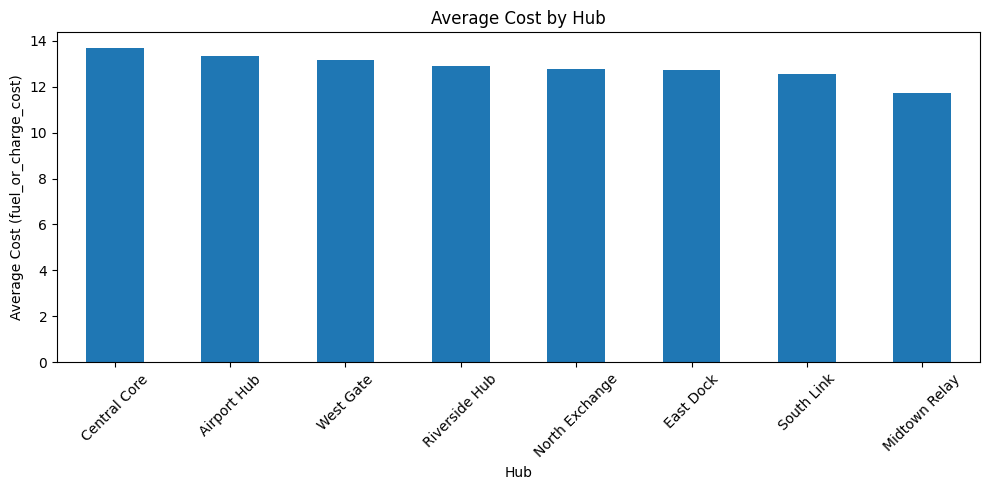

In [41]:
plt.figure(figsize=(10,5))
cost_by_hub.plot(kind="bar")
plt.title("Average Cost by Hub")
plt.xlabel("Hub")
plt.ylabel(f"Average Cost ({cost_col})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
import os
os.listdir("/content")

['.config', 'sample_data']

In [9]:
import os
os.listdir("/")

['mnt',
 'etc',
 'proc',
 'dev',
 'lib32',
 'opt',
 'lib64',
 'bin',
 'lib',
 'usr',
 'boot',
 'libx32',
 'media',
 'sbin',
 'srv',
 'sys',
 'run',
 'home',
 'tmp',
 'root',
 'var',
 'kaggle',
 'northstar_dataset.zip',
 '.dockerenv',
 'datalab',
 'tools',
 'content',
 'python-apt',
 'python-apt.tar.xz']

In [10]:
import zipfile
import os

zip_path = "/northstar_dataset.zip"
extract_path = "/content/northstar_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir("/content/northstar_dataset/northstar_dataset")

['deliveries.csv',
 'orders.csv',
 'hubs.csv',
 'customers.csv',
 'app_events.csv',
 'data_dictionary.csv',
 'complaints.csv',
 'incidents.csv',
 'vehicles.csv',
 'README.txt',
 'drivers.csv']

In [11]:
import pandas as pd
import numpy as np
import os

# Correct dataset folder path
path = "/content/northstar_dataset/northstar_dataset"

# Load all CSV files
orders = pd.read_csv(f"{path}/orders.csv")
deliveries = pd.read_csv(f"{path}/deliveries.csv")
customers = pd.read_csv(f"{path}/customers.csv")
complaints = pd.read_csv(f"{path}/complaints.csv")
incidents = pd.read_csv(f"{path}/incidents.csv")
drivers = pd.read_csv(f"{path}/drivers.csv")
vehicles = pd.read_csv(f"{path}/vehicles.csv")
hubs = pd.read_csv(f"{path}/hubs.csv")
app_events = pd.read_csv(f"{path}/app_events.csv")

print("All CSV files loaded successfully.")

# Clean zone names
def clean_zone(value):
    if pd.isna(value):
        return value
    return str(value).strip().title()

orders["pickup_zone"] = orders["pickup_zone"].apply(clean_zone)
orders["dropoff_zone"] = orders["dropoff_zone"].apply(clean_zone)
customers["home_zone"] = customers["home_zone"].apply(clean_zone)
drivers["base_zone"] = drivers["base_zone"].apply(clean_zone)
vehicles["assigned_zone"] = vehicles["assigned_zone"].apply(clean_zone)
hubs["zone"] = hubs["zone"].apply(clean_zone)
app_events["zone_context"] = app_events["zone_context"].apply(clean_zone)

print("Zone names cleaned successfully.")

# Convert date/time columns
orders["order_created_at"] = pd.to_datetime(orders["order_created_at"], errors="coerce")
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"], errors="coerce")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce")
customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors="coerce")
complaints["created_at"] = pd.to_datetime(complaints["created_at"], errors="coerce")
incidents["reported_at"] = pd.to_datetime(incidents["reported_at"], errors="coerce")
app_events["event_timestamp"] = pd.to_datetime(app_events["event_timestamp"], errors="coerce")

print("Date/time columns converted successfully.")

# Calculate actual delivery hours
deliveries["actual_delivery_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

# Remove negative values if any
deliveries["actual_delivery_hours"] = deliveries["actual_delivery_hours"].apply(
    lambda x: np.nan if x < 0 else x
)

print("Actual delivery hours calculated successfully.")

# Merge main operational data
main_df = orders.merge(deliveries, on="order_id", how="left")
main_df = main_df.merge(customers, on="customer_id", how="left")
main_df = main_df.merge(hubs, on="hub_id", how="left", suffixes=("", "_hub"))
main_df = main_df.merge(drivers, on="driver_id", how="left", suffixes=("", "_driver"))
main_df = main_df.merge(vehicles, on="vehicle_id", how="left", suffixes=("", "_vehicle"))

print("Orders, deliveries, customers, hubs, drivers and vehicles merged successfully.")

# Complaint summary
complaint_summary = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    avg_resolution_days=("resolution_days", "mean"),
    total_compensation=("compensation_amount", "sum")
).reset_index()

main_df = main_df.merge(complaint_summary, on="order_id", how="left")

main_df["complaint_count"] = main_df["complaint_count"].fillna(0)
main_df["avg_resolution_days"] = main_df["avg_resolution_days"].fillna(0)
main_df["total_compensation"] = main_df["total_compensation"].fillna(0)
main_df["complaint_flag"] = np.where(main_df["complaint_count"] > 0, 1, 0)

print("Complaint indicators added successfully.")

# Incident summary
incident_summary = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count"),
    avg_resolved_hours=("resolved_hours", "mean")
).reset_index()

main_df = main_df.merge(incident_summary, on="delivery_id", how="left")

main_df["incident_count"] = main_df["incident_count"].fillna(0)
main_df["avg_resolved_hours"] = main_df["avg_resolved_hours"].fillna(0)
main_df["incident_flag"] = np.where(main_df["incident_count"] > 0, 1, 0)

print("Incident indicators added successfully.")

# Delay flag
main_df["delay_flag"] = np.where(
    main_df["actual_delivery_hours"] > main_df["promised_window_hours"],
    1,
    0
)

print("Delay flag created successfully.")

# Save cleaned integrated dataset
main_df.to_csv("/content/northstar_integrated_cleaned.csv", index=False)

print("Integrated cleaned dataset saved successfully.")
print("Final dataset shape:", main_df.shape)

main_df.head()

All CSV files loaded successfully.
Zone names cleaned successfully.
Date/time columns converted successfully.
Actual delivery hours calculated successfully.
Orders, deliveries, customers, hubs, drivers and vehicles merged successfully.
Complaint indicators added successfully.
Incident indicators added successfully.
Delay flag created successfully.
Integrated cleaned dataset saved successfully.
Final dataset shape: (1250, 58)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,maintenance_status,telematics_version,complaint_count,avg_resolution_days,total_compensation,complaint_flag,incident_count,avg_resolved_hours,incident_flag,delay_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,InRepair,v2.0,0.0,0.0,0.00,0,0.0,0.0,0,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,...,NaN,NaN,0.0,0.0,0.00,0,0.0,0.0,0,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,Active,v2.0,1.0,2.0,8.66,1,0.0,0.0,0,1
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,Active,v2.2,0.0,0.0,0.00,0,0.0,0.0,0,0
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,Active,v2.1,1.0,8.0,54.41,1,0.0,0.0,0,0


In [12]:
import os
os.listdir("/content")

['.config',
 'northstar_dataset',
 'northstar_integrated_cleaned.csv',
 'sample_data']

In [13]:
rating_by_status = main_df.groupby("delivery_status")["customer_rating_post_delivery"].mean().sort_values()

rating_by_status

,customer_rating_post_delivery
delivery_status,
Failed,3.049313
Delayed,3.114975
OnTime,4.283273


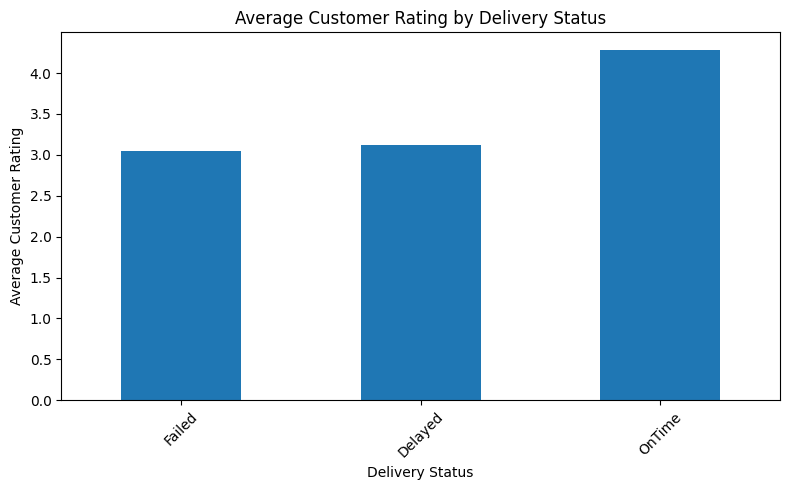

In [14]:
plt.figure(figsize=(8,5))
rating_by_status.plot(kind="bar")
plt.title("Average Customer Rating by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Customer Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
incident_type_count = incidents["incident_type"].value_counts()

incident_type_count

,count
incident_type,
ProofMissing,46
CustomerNoShow,44
RouteDeviation,43
VehicleFault,37
BatteryAlert,36
AppSyncError,31
TemperatureIssue,29
SafetyNearMiss,14


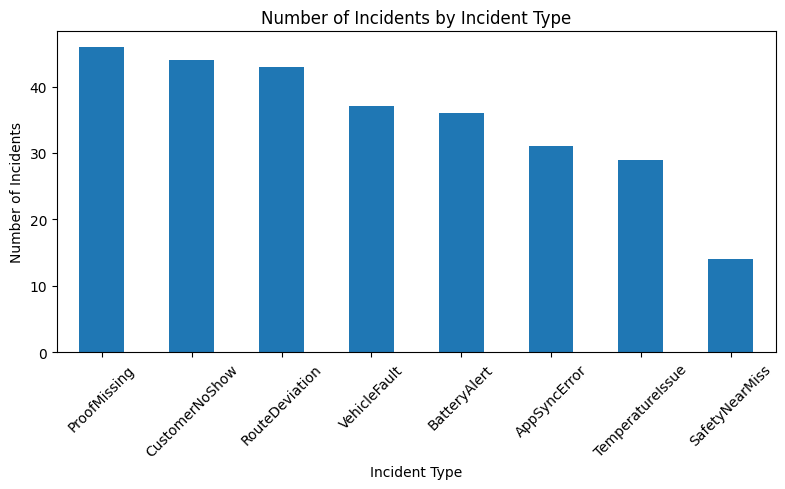

In [16]:
plt.figure(figsize=(8,5))
incident_type_count.plot(kind="bar")
plt.title("Number of Incidents by Incident Type")
plt.xlabel("Incident Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
complaint_type_count = complaints["complaint_type"].value_counts()

complaint_type_count

,count
complaint_type,
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


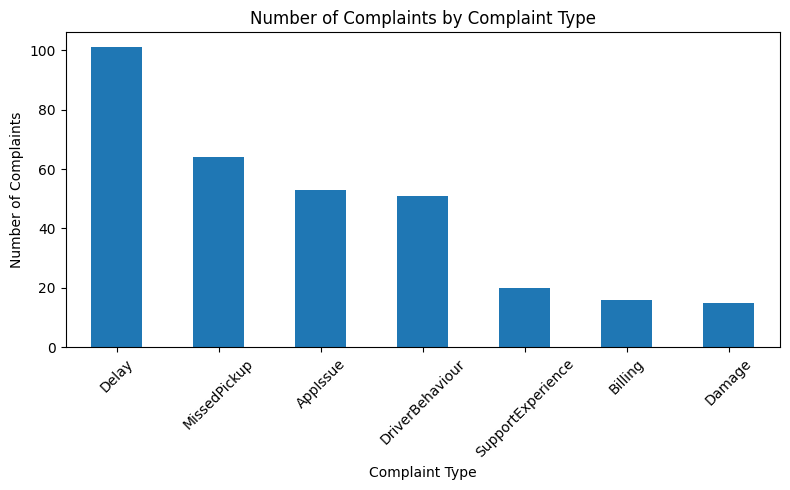

In [18]:
plt.figure(figsize=(8,5))
complaint_type_count.plot(kind="bar")
plt.title("Number of Complaints by Complaint Type")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()